In [186]:
import pandas as pd
df=pd.read_csv(r"C:\Users\onc\Downloads\Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [187]:
df.shape

(10000, 14)

In [188]:
# .tenure-Number of years the customer has been with the bank.
# .credit score-Credit Score is a number that represents how trustworthy a person is at repaying borrowed money.
# .we drop RowNumber, CustomerId, and Surname
# .Numerical features (e.g., Age, Balance)
# .Categorical features that need encoding (Geography, Gender)
# .A binary target (Exited), making it a binary classification problem similar to Titanic, but with more data.


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [190]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [191]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [192]:
#Drop Unnecessary data.

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

In [193]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [194]:
# Separate Features (X) and Target (y)

X = df.drop('Exited', axis=1)
y = df['Exited']

In [195]:
# Encoding

from sklearn.preprocessing import LabelEncoder

# Label Encode Gender
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])

In [196]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [197]:
#one hot encoding

X = pd.get_dummies(X, columns=['Geography'], dtype=int)

In [198]:
#Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [199]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [200]:
#EDA

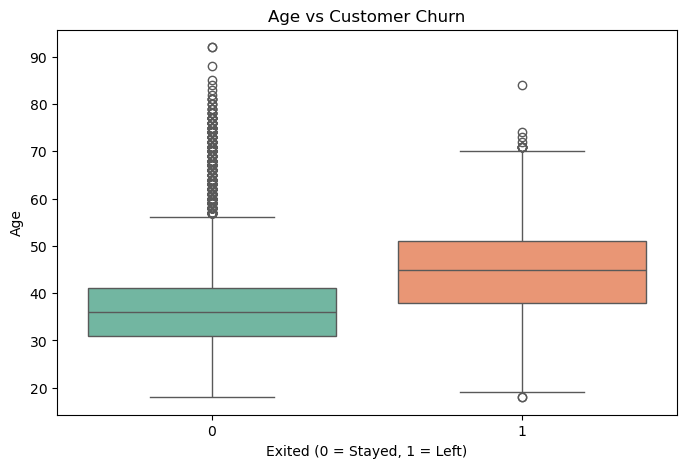

In [201]:
#age vs exit
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Age",
    data=df,
    palette="Set2",
    hue="Exited",
    legend=False
)

plt.title("Age vs Customer Churn")
plt.xlabel("Exited (0 = Stayed, 1 = Left)")
plt.ylabel("Age")

plt.show()

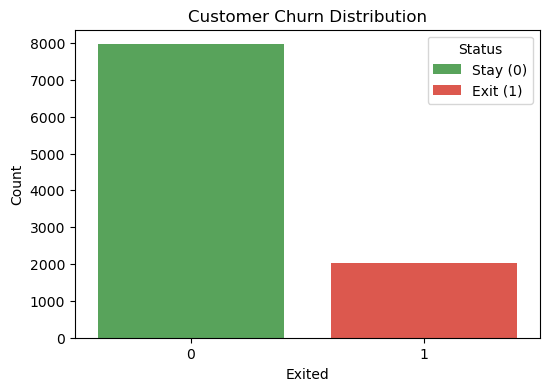

In [216]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Exited',
    data=df,
    hue='Exited',
    palette=['#4CAF50', '#F44336']
)

plt.legend(title="Status", labels=["Stay (0)", "Exit (1)"])

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Count")

plt.show()

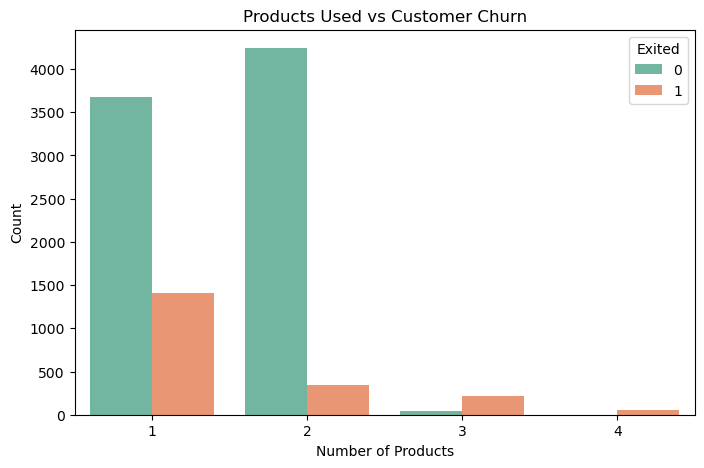

In [202]:
#number of product vs exit

plt.figure(figsize=(8,5))

sns.countplot(
    x="NumOfProducts",
    hue="Exited",
    data=df,
    palette="Set2"
)

plt.title("Products Used vs Customer Churn")
plt.xlabel("Number of Products")
plt.ylabel("Count")

plt.show()

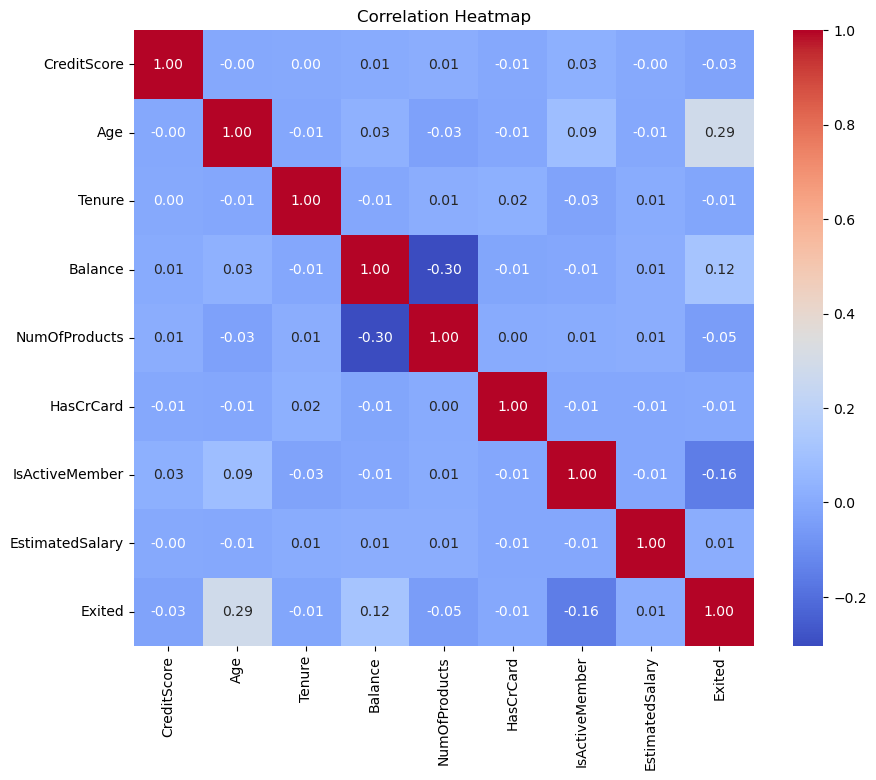

In [203]:
#correlation heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [204]:
#Feature scaling-Since ANN is sensitive to the scale of input features, scale the data using StandardScaler.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




In [205]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Number of input features
n_features = X_train.shape[1]

# Build ANN
model = Sequential()

# Input layer
model.add(Input(shape=(n_features,)))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Hidden Layer 3
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output Layer (Binary Classification)
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()



Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,481 (48.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [206]:
print(df['Exited'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


In [207]:

early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=25,
    verbose=1,
    mode="min",
    restore_best_weights=True
)


history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7106 - loss: 0.5818 - val_accuracy: 0.8431 - val_loss: 0.4050
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8091 - loss: 0.4405 - val_accuracy: 0.8662 - val_loss: 0.3488
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8241 - loss: 0.4157 - val_accuracy: 0.8731 - val_loss: 0.3376
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8306 - loss: 0.3944 - val_accuracy: 0.8706 - val_loss: 0.3312
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8394 - loss: 0.3856 - val_accuracy: 0.8675 - val_loss: 0.3312
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8358 - loss: 0.3817 - val_accuracy: 0.8712 - val_loss: 0.3301
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8420 - loss: 0.3801 - val_accuracy: 0.8737 - val_loss: 0.3299
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8402 - loss: 0.3734 - val_accuracy: 0.

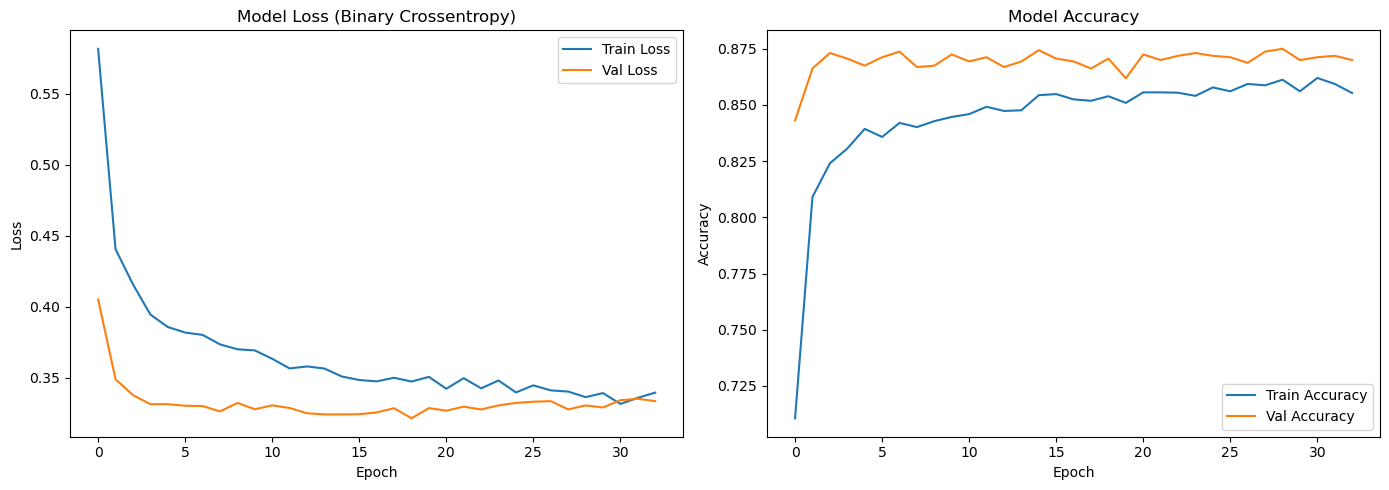

In [209]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss (Binary Crossentropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [212]:
y_pred_prob = model.predict(X_test).flatten()

y_test_arr = y_test.values

for actual, pred in zip(y_test_arr[10:20], y_pred_prob[10:20]):
    pred_class = 1 if pred > 0.5 else 0   # threshold tuning
    print(f"Actual: {actual}   Prob: {pred:.4f}   Predicted Class: {pred_class}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Actual: 1   Prob: 0.5290   Predicted Class: 1
Actual: 0   Prob: 0.4824   Predicted Class: 0
Actual: 0   Prob: 0.0182   Predicted Class: 0
Actual: 0   Prob: 0.0840   Predicted Class: 0
Actual: 0   Prob: 0.1052   Predicted Class: 0
Actual: 0   Prob: 0.0088   Predicted Class: 0
Actual: 0   Prob: 0.0552   Predicted Class: 0
Actual: 0   Prob: 0.0642   Predicted Class: 0
Actual: 1   Prob: 0.5848   Predicted Class: 1
Actual: 0   Prob: 0.3284   Predicted Class: 0


In [218]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict probabilities
y_pred_prob = model.predict(X_test).flatten()

# Convert probabilities to classes
y_pred = (y_pred_prob > 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy : 0.8625
Precision: 0.8113
Recall   : 0.4226
F1-Score : 0.5557
